# LitEval: Human-Relative Distance and Translation Quality

- **Goal:** Is a model translation's distance from the human translations of the same source segment associated with MQM quality?
- **Data:** student-annotated German–English LitEval subset, only machine translations enter the quality models
- **Predictor:** `r_mean`, the mean distance to the human references relative to held-out human translations
- **Outcomes:** `Overall` MQM (primary) and Accuracy, Fluency, Style, Terminology (secondary)
- **Model:** one mixed model per diversity dimension with Segment and Model as crossed random intercepts (as in HANNA)
- **Narrative:** exploratory, only available for very few segments

## Setup

In [1]:
import pathlib
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests
from tqdm.auto import tqdm

# Warnings are not suppressed globally: mixed-model warnings are captured per fit and reported below
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Output locations (relative to quality/)
RESULTS_DIR = pathlib.Path('results')
FIGURE_DIR = pathlib.Path('../figures/quality_analysis')   # shared with the HANNA notebook
for _dir in (RESULTS_DIR, FIGURE_DIR):
    _dir.mkdir(parents=True, exist_ok=True)


def save_figure(filename, **kwargs):
    """Save the current figure to FIGURE_DIR and return the path."""
    kwargs.setdefault('dpi', 300)
    kwargs.setdefault('bbox_inches', 'tight')
    path = FIGURE_DIR / filename
    plt.savefig(path, **kwargs)
    print(f'Saved: {path}')
    return path

/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load & Prepare LitEval

- `translator1`–`translator3` stay distinct in `Original_Model` and are collapsed to `translator` in `Model`
- MQM sub-scores (Accuracy, Fluency, Style, Terminology) are joined from `metric_df.csv`
- Main sample: segments with ≥ 2 human translations; sensitivity sample: ≥ 3

In [2]:
STUDENT_ANNOTATION_PATH = '../data/LITEVAL-CORPUS/human evalution/Student_annotation_2_de-en.csv'
METRIC_DF_PATH = '../data/liteval_corpus/codes/metric_df.csv'

# Load the student annotations and metric dataframe
sa = pd.read_csv(STUDENT_ANNOTATION_PATH)
metric_df = pd.read_csv(METRIC_DF_PATH)
print(f'Student annotations (de-en): {len(sa)} rows')

# Help function to map model names to a standardized format
def map_model(model):
    model = str(model)
    return 'translator' if model.startswith('translator') else model.replace(' ', '_')


sa['Original_Model'] = sa['model'].astype(str)
sa['is_human'] = sa['Original_Model'].str.startswith('translator')
sa['Model'] = sa['Original_Model'].apply(map_model)

# metric_df only stores the first 20 characters of source and target -> join on those plus model and MQM score
sa['_src20'] = sa['source'].str[:20]
sa['_tgt20'] = sa['tgt'].str[:20]
sa['_mqm_r'] = sa['mqm_score'].round(4)


# Filter the metric dataframe for the 'de-en' language pair and prepare it for merging with the student annotations
metric_de = metric_df.loc[metric_df['pair'] == 'de-en'].copy()
metric_de['mqm_r'] = metric_de['mqm_score'].round(4)
join_key = ['source_', 'tgt_', 'model_human', 'mqm_r']
metric_dedup = metric_de.drop_duplicates(subset=join_key, keep='first')
metric_dedup['_model_join'] = metric_dedup['model_human']

sa['_model_join'] = np.where(sa['is_human'], 'translator', sa['Original_Model'])
sub_cols = ['mqm_score_acc', 'mqm_score_fluency', 'mqm_score_style', 'mqm_score_term']


# Merge the student annotations with the metric dataframe on the specified keys, keeping only the relevant columns from both dataframes.
translations = sa.merge(
    metric_dedup[
        ['source_', 'tgt_', '_model_join', 'mqm_r'] + sub_cols
    ],
    left_on=['_src20', '_tgt20', '_model_join', '_mqm_r'],
    right_on=['source_', 'tgt_', '_model_join', 'mqm_r'],
    how='left',
    validate='many_to_one',
)

# Unique row ID per translation, keeping the three human translators of a segment apart
translations['Segment_ID'] = translations['source'].astype('category').cat.codes
translations['_occurrence'] = translations.groupby(
    ['Segment_ID', 'Original_Model'], sort=False
).cumcount()
translations['Row ID'] = (
    translations['Segment_ID'].astype(str)
    + '_'
    + translations['Original_Model']
    + '_'
    + translations['_occurrence'].astype(str)
)

translations = translations.rename(columns={
    'tgt': 'Text',
    'mqm_score_acc': 'MQM_Accuracy',
    'mqm_score_fluency': 'MQM_Fluency',
    'mqm_score_style': 'MQM_Style',
    'mqm_score_term': 'MQM_Terminology',
    'mqm_score': 'Overall',
})


HUMAN_CRITERIA = ['MQM_Accuracy', 'MQM_Fluency', 'MQM_Style', 'MQM_Terminology']
PRIMARY_TARGET = 'Overall'
SUPPLEMENTARY_TARGETS = HUMAN_CRITERIA
TARGETS = [PRIMARY_TARGET] + SUPPLEMENTARY_TARGETS

translations['word_count'] = translations['Text'].astype(str).str.split().str.len()
translations['log_word_count'] = np.log(translations['word_count'].clip(lower=1))

keep_cols = [
    'Row ID', 'Segment_ID', 'Original_Model', 'Model', 'is_human',
    'source', 'Text', 'word_count', 'log_word_count',
] + HUMAN_CRITERIA + ['Overall']
translations = translations[keep_cols].reset_index(drop=True)

assert translations['Row ID'].is_unique, 'Row ID must be unique.'

n_unmatched = translations['MQM_Accuracy'].isna().sum()
print(f'MQM sub-dimension join: {len(translations) - n_unmatched}/{len(translations)} matched')
print(f'Translation instances: {len(translations)}')
print(f'Source segments: {translations["Segment_ID"].nunique()}')

human_counts = (
    translations.loc[translations['is_human']]
    .groupby('Segment_ID')
    .size()
)
all_segments = translations['Segment_ID'].nunique()

print('\nSegments by number of human translations:')
display(human_counts.value_counts().sort_index().rename('n_segments').to_frame())
print(f'Segments with no human translation: {all_segments - len(human_counts)}')
print(f'Main sample (>=2 humans): {(human_counts >= 2).sum()} segments')
print(f'Sensitivity sample (>=3 humans): {(human_counts >= 3).sum()} segments')

Student annotations (de-en): 507 rows
MQM sub-dimension join: 503/507 matched
Translation instances: 507
Source segments: 56

Segments by number of human translations:


,n_segments
1,20
2,5
3,21


Segments with no human translation: 10
Main sample (>=2 humans): 26 segments
Sensitivity sample (>=3 humans): 21 segments


## Human-Relative Distance Scores

- Same pairwise metrics and reference-control construction as WritingPrompts/PAR3 and HANNA
- Human translations come first in each segment's distance matrix
- Leave-one-out splits (`REF_SIZE = n_h - 1`): each human translation is the control once
- `delta(t)`: distance to `H_ref`, averaged over all splits in which `t` is not part of `H_ref`
- `r(t) = delta(t) / median delta` of the segment's human-control translations
- `r_mean` (primary) and `r_nearest` (robustness)

In [3]:
def find_repo_root(start=None):
    start = pathlib.Path(start or pathlib.Path.cwd())
    for p in [start, *start.parents]:
        if (p / 'metrics' / 'metrics_lib').is_dir():
            return p
    raise FileNotFoundError("Could not locate repository root with 'metrics/metrics_lib/'.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from metrics.metrics_lib.pairwise import (
    distance_matrix,
    style_distance_matrices,
    reference_control_splits_rowwise,
)

### Cache & Eligible Segments

- Scores are cached in `liteval_human_relative_scores_split_control_v3.csv`
- The cache is only reused if it covers exactly the current translations and all six dimensions

In [4]:
# v3 = thesis-wide reference-control normalization; older caches must not be reused
REFERENCE_CACHE = RESULTS_DIR / 'liteval_human_relative_scores_split_control_v3.csv'

METRICS = ['sem', 'lex', 'syn', 'disc', 'narr', 'style']
PAIRWISE_METRIC_NAMES = {
    'sem': 'D_sem',
    'lex': 'D_lex',
    'syn': 'D_syn',
    'disc': 'D_disc',
    'narr': 'D_narr',
}
METRIC_LABELS = {
    'sem': 'Semantic',
    'lex': 'Lexical',
    'syn': 'Syntactic',
    'disc': 'Discourse',
    'narr': 'Narrative',
    'style': 'Stylistic',
}

eligible_segments = human_counts.loc[human_counts >= 2].index
three_ref_segments = human_counts.loc[human_counts >= 3].index

translations_ref = translations.loc[
    translations['Segment_ID'].isin(eligible_segments)
].copy()

# Human and model translations both get an r(t) row
expected_ids = set(translations_ref['Row ID'])

scores_long = None
required_cache_cols = {
    'Row ID', 'Segment_ID', 'Model', 'Original_Model', 'metric',
    'delta', 'baseline', 'r',
    'delta_nearest', 'baseline_nearest', 'r_nearest',
    'n_human_refs_total', 'n_human_controls_valid',
    'n_splits_mean', 'n_splits_nearest',
}

# Check if a compatible human-relative score cache exists and load it if valid; otherwise, recompute the scores.
if REFERENCE_CACHE.exists():
    candidate = pd.read_csv(REFERENCE_CACHE)
    cached_ids = set(candidate['Row ID']) if 'Row ID' in candidate else set()
    cached_metrics = set(candidate['metric']) if 'metric' in candidate else set()

    if (
        required_cache_cols.issubset(candidate.columns)
        and cached_ids == expected_ids
        and cached_metrics == set(METRICS)
    ):
        scores_long = candidate
        print(f'Loaded human-relative scores from {REFERENCE_CACHE}.')
    else:
        print('Existing human-relative cache does not match the current data; recomputing.')
        
else:
    print('No compatible human-relative cache found; recomputing with split/control normalization.')

print(f'Eligible main-sample segments: {translations_ref["Segment_ID"].nunique()}')
print(f'Model translations in main sample: {int((~translations_ref["is_human"]).sum())}')
print(f'Human translations in main sample: {int(translations_ref["is_human"].sum())}')

Loaded human-relative scores from results/liteval_human_relative_scores_split_control_v3.csv.
Eligible main-sample segments: 26
Model translations in main sample: 234
Human translations in main sample: 73


### Pairwise Matrices

- Only computed if the score cache is missing or outdated
- Stylistic distance for all segments in one call (joint winsorization and min-max normalization)

In [5]:
# Compute pairwise distance matrices for each metric and segment, as well as style distance matrices, if the scores have not been loaded from a valid cache.
if scores_long is None:
    # reference_control_splits_rowwise expects the human translations in the first rows
    ordered_groups = {}

    for segment_id, group in translations_ref.groupby('Segment_ID', sort=True):
        humans = group.loc[group['is_human']].copy()
        models = group.loc[~group['is_human']].copy()
        ordered_groups[segment_id] = pd.concat([humans, models], ignore_index=True)

    pairing_matrices = {}

    # Compute pairwise distance matrices for each metric and segment, handling exceptions and reporting progress.
    for metric, metric_name in PAIRWISE_METRIC_NAMES.items():
        for segment_id, group in tqdm(ordered_groups.items(), desc=metric):
            try:
                pairing_matrices[(metric, segment_id)] = distance_matrix(
                    metric_name,
                    group['Text'].tolist(),
                )
            except Exception as exc:
                warnings.warn(
                    f'{metric}, segment {segment_id}: {exc!r}'
                )
                pairing_matrices[(metric, segment_id)] = None

        ok = sum(
            pairing_matrices.get((metric, segment_id)) is not None
            for segment_id in ordered_groups
        )
        print(f'{metric}: {ok}/{len(ordered_groups)} matrices computed')

    # Style components are normalized jointly across segments -> one call for all blocks
    style_texts = {
        segment_id: group['Text'].tolist()
        for segment_id, group in ordered_groups.items()
    }
    style_matrices = style_distance_matrices(style_texts)
    for segment_id, matrix in style_matrices.items():
        pairing_matrices[('style', segment_id)] = matrix

    ok_style = sum(
        pairing_matrices.get(('style', segment_id)) is not None
        for segment_id in ordered_groups
    )
    print(f'style: {ok_style}/{len(ordered_groups)} matrices computed')
    
else:
    ordered_groups = None
    pairing_matrices = None
    print('Skipped pairwise-matrix computation because the v3 score cache is valid.')

Skipped pairwise-matrix computation because the v3 score cache is valid.


### Reference-Control Split Scores

- One row per translation (human and model) and dimension
- Baseline = median `delta` of the segment's human-control translations, separately for mean and nearest distance

In [6]:
EPS = 1e-12


def split_control_scores_from_matrix(group, metric, matrix):
    """Leave-one-out r_mean / r_nearest for every translation of one segment and dimension.

    `group` lists the human translations first, then the model translations.
    """
    group = group.reset_index(drop=True)
    matrix = np.asarray(matrix, dtype=float)

    # Check that there are at least two human translations to compute scores.
    n = len(group)
    n_human = int(group['is_human'].sum())
    if n_human < 2:
        return []

    # Check that the matrix shape matches the number of translations in the group.
    if matrix.shape != (n, n):
        raise ValueError(
            f'{metric}/{group["Segment_ID"].iloc[0]}: matrix shape {matrix.shape} '
            f'does not match {n} texts.'
        )

    ref_size = n_human - 1

    # Initialize arrays to accumulate the mean and nearest distances for each translation across the splits.
    sum_mean = np.zeros(n, dtype=float)
    cnt_mean = np.zeros(n, dtype=int)
    sum_min = np.zeros(n, dtype=float)
    cnt_min = np.zeros(n, dtype=int)

    # Average each text's distance to H_ref over the splits in which it is not part of H_ref
    for _, ref_idx, row_mean, row_min in reference_control_splits_rowwise(
        matrix, n_human, ref_size
    ):
        eligible = np.ones(n, dtype=bool)
        eligible[ref_idx] = False

        # Accumulate the mean and nearest distances for eligible translations
        ok_mean = eligible & np.isfinite(row_mean)
        sum_mean[ok_mean] += row_mean[ok_mean]
        cnt_mean[ok_mean] += 1

        # Accumulate the nearest distances for eligible translations
        ok_min = eligible & np.isfinite(row_min)
        sum_min[ok_min] += row_min[ok_min]
        cnt_min[ok_min] += 1

    # Compute the mean and nearest distances for each translation, handling cases with no valid splits.
    delta_mean = np.full(n, np.nan, dtype=float)
    delta_nearest = np.full(n, np.nan, dtype=float)

    # Compute the mean distances for translations with valid splits
    ok = cnt_mean > 0
    delta_mean[ok] = sum_mean[ok] / cnt_mean[ok]

    # Compute the nearest distances for translations with valid splits
    ok = cnt_min > 0
    delta_nearest[ok] = sum_min[ok] / cnt_min[ok]

    # Baseline: median delta of the human translations (each scored as control)
    human_mean = delta_mean[:n_human]
    human_nearest = delta_nearest[:n_human]

    valid_human_mean = human_mean[np.isfinite(human_mean)]
    valid_human_nearest = human_nearest[np.isfinite(human_nearest)]

    baseline = (
        float(np.median(valid_human_mean))
        if len(valid_human_mean) else np.nan
    )
    baseline_nearest = (
        float(np.median(valid_human_nearest))
        if len(valid_human_nearest) else np.nan
    )

    rows = []
    for row_i in range(n):
        row = group.iloc[row_i]

        r_value = (
            delta_mean[row_i] / baseline
            if (
                np.isfinite(delta_mean[row_i])
                and np.isfinite(baseline)
                and baseline > EPS
            )
            else np.nan
        )
        r_nearest = (
            delta_nearest[row_i] / baseline_nearest
            if (
                np.isfinite(delta_nearest[row_i])
                and np.isfinite(baseline_nearest)
                and baseline_nearest > EPS
            )
            else np.nan
        )

        rows.append({
            'Row ID': row['Row ID'],
            'Segment_ID': row['Segment_ID'],
            'Model': row['Model'],
            'Original_Model': row['Original_Model'],
            'metric': metric,
            'delta': delta_mean[row_i],
            'baseline': baseline,
            'r': r_value,
            'delta_nearest': delta_nearest[row_i],
            'baseline_nearest': baseline_nearest,
            'r_nearest': r_nearest,
            'n_human_refs_total': n_human,
            'n_human_controls_valid': len(valid_human_mean),
            'n_splits_mean': int(cnt_mean[row_i]),
            'n_splits_nearest': int(cnt_min[row_i]),
        })

    return rows

# If the human-relative scores have not been loaded from a valid cache, compute them for each metric and segment
if scores_long is None:
    score_rows = []

    for metric in METRICS:
        for segment_id, group in tqdm(ordered_groups.items(), desc=f'scoring {metric}'):
            matrix = pairing_matrices.get((metric, segment_id))
            if matrix is None:
                continue
            score_rows.extend(
                split_control_scores_from_matrix(group, metric, matrix)
            )

    scores_long = pd.DataFrame(score_rows)
    scores_long.to_csv(REFERENCE_CACHE, index=False)
    print(f'Saved {len(scores_long)} human+model-by-metric scores to {REFERENCE_CACHE}.')

assert not scores_long.duplicated(['Row ID', 'metric']).any(), (
    'Each translation (human or model) must have at most one row per metric.'
)

display(scores_long.head())

,Row ID,Segment_ID,Model,Original_Model,metric,delta,baseline,r,delta_nearest,baseline_nearest,r_nearest,n_human_refs_total,n_human_controls_valid,n_splits_mean,n_splits_nearest
0,0_translator2_0,0,translator,translator2,sem,0.072155,0.055351,1.303604,0.063942,0.030332,2.108041,3,3,1,1
1,0_translator3_0,0,translator,translator3,sem,0.047137,0.055351,0.851606,0.030332,0.030332,1.000000,3,3,1,1
2,0_translator1_0,0,translator,translator1,sem,0.055351,0.055351,1.000000,0.030332,0.030332,1.000000,3,3,1,1
3,0_m2m_0,0,m2m,m2m,sem,0.129316,0.055351,2.336300,0.121329,0.030332,3.999982,3,3,3,3
4,0_nllb_0,0,nllb,nllb,sem,0.077226,0.055351,1.395217,0.064450,0.030332,2.124808,3,3,3,3


## Validation & Missingness

- Human–human baselines per segment: a very small baseline can produce extreme ratios
- Analysis table: model translations only, with `log(r)` for mean and nearest scores
- Length mismatch: mean absolute word-count difference to the segment's human translations
- Narrative availability is reported separately and does not restrict the other dimensions

In [7]:
def count_valid_segments(frame, value_col):
    return (
        frame.assign(_valid=frame[value_col].notna())
        .groupby('Segment_ID')['_valid']
        .any()
        .sum()
    )


# Valid scores and near-zero baselines per dimension
score_validation_rows = []
for metric in METRICS:
    subset = scores_long.loc[scores_long['metric'] == metric]
    segment_subset = subset.drop_duplicates('Segment_ID')
    score_validation_rows.append({
        'metric': metric,
        'rows': len(subset),
        'valid_r_mean': subset['r'].notna().sum(),
        'segments_r_mean': count_valid_segments(subset, 'r'),
        'valid_r_nearest': subset['r_nearest'].notna().sum(),
        'segments_r_nearest': count_valid_segments(subset, 'r_nearest'),
        'zero_or_tiny_mean_baselines': (segment_subset['baseline'] <= 1e-6).sum(),
        'zero_or_tiny_nearest_baselines': (segment_subset['baseline_nearest'] <= 1e-6).sum(),
    })

score_validation = pd.DataFrame(score_validation_rows).set_index('metric').reindex(METRICS)
display(score_validation)

# Baseline distribution (one value per segment and dimension)
segment_scores = scores_long.drop_duplicates(['Segment_ID', 'metric'])
baseline_rows = []
for metric in METRICS:
    metric_scores = segment_scores.loc[segment_scores['metric'] == metric]
    for score_type, column in [('mean', 'baseline'), ('nearest', 'baseline_nearest')]:
        values = metric_scores[column].dropna()
        baseline_rows.append({
            'metric': metric,
            'score_type': score_type,
            'n_segments': len(values),
            'min': values.min(),
            'p01': values.quantile(0.01),
            'p05': values.quantile(0.05),
            'median': values.median(),
            'max': values.max(),
            'n_le_1e-6': int((values <= 1e-6).sum()),
        })
baseline_diagnostics = pd.DataFrame(baseline_rows)
baseline_diagnostics.to_csv(
    RESULTS_DIR / 'liteval_human_relative_baseline_diagnostics.csv', index=False
)
print('Human-human baseline diagnostics (one value per segment and metric):')
display(baseline_diagnostics.round(6))


# Three smallest mean baselines in each dimension
smallest_baselines = (
    segment_scores
    .sort_values(['metric', 'baseline'])
    .groupby('metric', group_keys=False)
    .head(3)[['metric', 'Segment_ID', 'baseline', 'baseline_nearest',
             'n_human_controls_valid']]
)
print('Three smallest mean baselines in each dimension:')
display(smallest_baselines)

# Analysis table: model translations with one column per score and dimension
wide_parts = []
for value in ['delta', 'baseline', 'r', 'delta_nearest', 'baseline_nearest', 'r_nearest']:
    part = scores_long.pivot(index='Row ID', columns='metric', values=value)
    part.columns = [f'{value}_{metric}' for metric in part.columns]
    wide_parts.append(part)
scores_wide = pd.concat(wide_parts, axis=1).reset_index()

model_data = (
    translations_ref.loc[~translations_ref['is_human']]
    .merge(scores_wide, on='Row ID', how='left', validate='one_to_one')
    .copy()
)

# Length mismatch to the segment's human translations
length_rows = []
for segment_id, group in translations_ref.groupby('Segment_ID'):
    human_words = group.loc[group['is_human'], 'word_count'].to_numpy(dtype=float)
    human_log_words = group.loc[group['is_human'], 'log_word_count'].to_numpy(dtype=float)
    for _, row in group.loc[~group['is_human']].iterrows():
        length_rows.append({
            'Row ID': row['Row ID'],
            'length_mismatch_words': float(np.mean(np.abs(row['word_count'] - human_words))),
            'length_mismatch_log': float(np.mean(np.abs(row['log_word_count'] - human_log_words))),
        })

model_data = model_data.merge(
    pd.DataFrame(length_rows), on='Row ID', how='left', validate='one_to_one'
)

R_COLS = [f'r_{metric}' for metric in METRICS]
LOG_R_COLS = [f'log_r_{metric}' for metric in METRICS]
R_NEAREST_COLS = [f'r_nearest_{metric}' for metric in METRICS]
LOG_R_NEAREST_COLS = [f'log_r_nearest_{metric}' for metric in METRICS]

for r_col, log_col in zip(R_COLS, LOG_R_COLS):
    model_data[log_col] = np.where(
        model_data[r_col] > 0, np.log(model_data[r_col]), np.nan
    )
for r_col, log_col in zip(R_NEAREST_COLS, LOG_R_NEAREST_COLS):
    model_data[log_col] = np.where(
        model_data[r_col] > 0, np.log(model_data[r_col]), np.nan
    )

model_data.to_csv(RESULTS_DIR / 'liteval_human_relative_analysis_data.csv', index=False)

# Missing log(r) values per dimension
missingness_rows = []
for metric in METRICS:
    for score_type, log_col in [
        ('mean', f'log_r_{metric}'),
        ('nearest', f'log_r_nearest_{metric}'),
    ]:
        valid = model_data[log_col].notna()
        missingness_rows.append({
            'metric': metric,
            'score_type': score_type,
            'n_model_translations': len(model_data),
            'n_valid_r': int(valid.sum()),
            'n_missing_r': int((~valid).sum()),
            'n_segments_with_valid_r': model_data.loc[valid, 'Segment_ID'].nunique(),
        })
missingness = pd.DataFrame(missingness_rows)
display(missingness)

# Skewness of r vs. log(r)
ratio_distribution_rows = []
for metric in METRICS:
    for score_type, r_col, log_col in [
        ('mean', f'r_{metric}', f'log_r_{metric}'),
        ('nearest', f'r_nearest_{metric}', f'log_r_nearest_{metric}'),
    ]:
        valid = model_data[[r_col, log_col]].dropna()
        ratio_distribution_rows.append({
            'metric': metric,
            'score_type': score_type,
            'n': len(valid),
            'r_median': valid[r_col].median(),
            'r_p95': valid[r_col].quantile(0.95),
            'r_max': valid[r_col].max(),
            'r_skew': stats.skew(valid[r_col], bias=False) if len(valid) > 2 else np.nan,
            'log_r_skew': stats.skew(valid[log_col], bias=False) if len(valid) > 2 else np.nan,
        })
ratio_diagnostics = pd.DataFrame(ratio_distribution_rows)
ratio_diagnostics.to_csv(
    RESULTS_DIR / 'liteval_human_relative_ratio_diagnostics.csv', index=False
)
print('Ratio and log-ratio diagnostics:')
display(ratio_diagnostics.round(3))

narrative_segments = missingness.loc[
    (missingness['metric'] == 'narr') & (missingness['score_type'] == 'mean'),
    'n_segments_with_valid_r',
].iloc[0]
if narrative_segments < 15:
    print(
        f'NOTE: Narrative is available for only {narrative_segments} segments and '
        'is treated as exploratory in all inferential tables.'
    )

,rows,valid_r_mean,segments_r_mean,valid_r_nearest,segments_r_nearest,zero_or_tiny_mean_baselines,zero_or_tiny_nearest_baselines
metric,,,,,,,
sem,307,307,26,307,26,0,0
lex,307,307,26,307,26,0,0
syn,307,307,26,307,26,0,0
disc,307,206,20,182,18,1,3
narr,307,60,6,60,6,0,0
style,307,283,24,283,24,0,0


Human-human baseline diagnostics (one value per segment and metric):


,metric,score_type,n_segments,min,p01,p05,median,max,n_le_1e-6
0,sem,mean,26,0.015694,0.016036,0.017792,0.038746,0.085712,0
1,sem,nearest,26,0.010523,0.011388,0.014380,0.029509,0.085712,0
2,lex,mean,26,0.558993,0.564468,0.587208,0.682781,0.759935,0
3,lex,nearest,26,0.507937,0.514616,0.547069,0.672594,0.744770,0
4,syn,mean,26,0.250626,0.265386,0.312108,0.362633,0.492063,0
5,syn,nearest,26,0.212963,0.223282,0.256854,0.354715,0.444444,0
6,disc,mean,21,0.000000,0.000806,0.004031,0.076956,0.323465,1
7,disc,nearest,21,0.000000,0.000000,0.000000,0.042615,0.323465,3
8,narr,mean,6,1.964258,2.007090,2.178418,3.117024,3.988528,0
9,narr,nearest,6,1.964258,1.990614,2.096038,2.753898,3.426989,0


Three smallest mean baselines in each dimension:


,metric,Segment_ID,baseline,baseline_nearest,n_human_controls_valid
1028,disc,24,0.000000,0.000000,3
1192,disc,53,0.004031,0.001432,3
992,disc,14,0.011154,0.002669,3
602,lex,55,0.558993,0.534653,3
331,lex,7,0.580891,0.507937,3
366,lex,12,0.606157,0.584314,3
1455,narr,49,1.964258,1.964258,2
1323,narr,22,2.820899,2.820899,2
1407,narr,33,3.046583,2.731913,3
95,sem,22,0.015694,0.013985,3


,metric,score_type,n_model_translations,n_valid_r,n_missing_r,n_segments_with_valid_r
0,sem,mean,234,234,0,26
1,sem,nearest,234,234,0,26
2,lex,mean,234,234,0,26
3,lex,nearest,234,234,0,26
4,syn,mean,234,234,0,26
5,syn,nearest,234,234,0,26
6,disc,mean,234,154,80,19
7,disc,nearest,234,136,98,17
8,narr,mean,234,44,190,6
9,narr,nearest,234,44,190,6


Ratio and log-ratio diagnostics:


,metric,score_type,n,r_median,r_p95,r_max,r_skew,log_r_skew
0,sem,mean,234,1.128,2.259,5.091,2.061,0.427
1,sem,nearest,234,1.246,2.923,8.053,2.608,0.375
2,lex,mean,234,1.004,1.151,1.300,0.557,0.332
3,lex,nearest,234,1.011,1.203,1.447,0.868,0.535
4,syn,mean,234,0.977,1.315,1.672,1.003,0.437
5,syn,nearest,234,1.013,1.387,1.779,0.905,0.112
6,disc,mean,154,1.152,4.612,15.740,4.233,0.678
7,disc,nearest,136,1.184,12.573,58.265,5.850,0.863
8,narr,mean,44,0.853,1.213,1.870,1.823,0.177
9,narr,nearest,44,0.877,1.183,1.870,0.565,-0.820


NOTE: Narrative is available for only 6 segments and is treated as exploratory in all inferential tables.


## Descriptive Spearman Associations

- Pairwise ρ between `r_mean` and each MQM outcome
- Ignores dependence within segments → only ρ and n, no p-values

Saved: ../figures/quality_analysis/liteval_human_relative_spearman.png


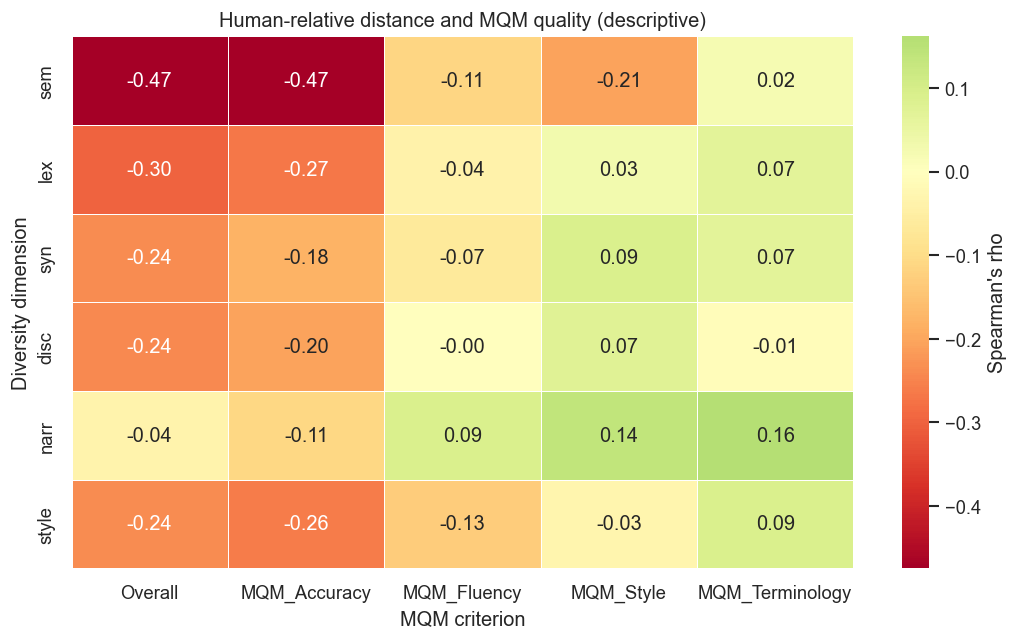

,metric,target,rho,n,outcome_role,dimension_role
0,sem,Overall,-0.4745,234,primary,confirmatory
1,sem,MQM_Accuracy,-0.4739,234,supplementary,confirmatory
2,sem,MQM_Fluency,-0.1115,234,supplementary,confirmatory
3,sem,MQM_Style,-0.2081,234,supplementary,confirmatory
4,sem,MQM_Terminology,0.0245,234,supplementary,confirmatory
5,lex,Overall,-0.2967,234,primary,confirmatory
6,lex,MQM_Accuracy,-0.2686,234,supplementary,confirmatory
7,lex,MQM_Fluency,-0.0410,234,supplementary,confirmatory
8,lex,MQM_Style,0.0325,234,supplementary,confirmatory
9,lex,MQM_Terminology,0.0655,234,supplementary,confirmatory


In [8]:
correlation_rows = []
for metric, r_col in zip(METRICS, R_COLS):
    for target in TARGETS:
        pair = model_data[[r_col, target]].dropna()
        rho = stats.spearmanr(pair[r_col], pair[target])[0] if len(pair) >= 3 else np.nan
        correlation_rows.append({
            'metric': metric,
            'target': target,
            'rho': rho,
            'n': len(pair),
            'outcome_role': 'primary' if target == PRIMARY_TARGET else 'supplementary',
            'dimension_role': 'exploratory' if metric == 'narr' else 'confirmatory',
        })

correlations = pd.DataFrame(correlation_rows)
correlations.to_csv(RESULTS_DIR / 'liteval_human_relative_spearman.csv', index=False)

rho_matrix = (
    correlations.pivot(index='metric', columns='target', values='rho')
    .reindex(index=METRICS, columns=TARGETS)
)
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(
    rho_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': "Spearman's rho"},
    ax=ax,
)
ax.set_title('Human-relative distance and MQM quality (descriptive)')
ax.set_xlabel('MQM criterion')
ax.set_ylabel('Diversity dimension')
plt.tight_layout()
save_figure('liteval_human_relative_spearman.png')
plt.show()

display(correlations.round(4))

## Mixed-Effects Models

- `Q ~ z[log r_mean] + (1 | Segment) + (1 | Model)`, one model per outcome and dimension
- Standardization within the sample of each model
- FDR families: 6 `Overall` tests (primary), 24 criterion tests (secondary)

In [9]:
LMM_METHODS = ['lbfgs', 'bfgs', 'cg', 'powell', 'nm']
LMM_MAXITER = 500
RANDOM_EFFECT_BOUNDARY = 1e-8


def fit_robust_mixedlm(model, label):
    """Try each optimizer in turn; return the first converged fit, else the best one by log-likelihood.

    Returns (result, optimizer, captured warning messages).
    """
    best = None
    best_method = None
    best_warnings = []
    errors = []

    # Try each optimizer in turn, capturing warnings and errors, and return the first successful fit or the best one by log-likelihood.
    for method in LMM_METHODS:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always')
            try:
                result = model.fit(reml=True, method=method, maxiter=LMM_MAXITER)
            except Exception as error:
                errors.append(f'{method}: {error!r}')
                continue

        warning_messages = sorted({str(item.message) for item in caught})
        if result.converged:
            return result, method, warning_messages

        if best is None or result.llf > best.llf:
            best = result
            best_method = method
            best_warnings = warning_messages

    # If no optimizer converged, return the best fit by log-likelihood along with a warning message.
    if best is not None:
        best_warnings = best_warnings + [
            f'{label}: no optimizer converged; returning best log-likelihood fit.'
        ]
        return best, best_method, best_warnings

    raise RuntimeError(f'{label}: every optimizer failed. ' + ' | '.join(errors))


def crossed_mixedlm(formula, data):
    """`formula + (1 | Segment_ID) + (1 | Model)`.

    MixedLM accepts only one `groups` argument, so all rows go into one dummy group
    and Segment / Model enter as independent variance components.
    """
    data = data.assign(_grp=1)
    vc = {'Segment': '0 + C(Segment_ID)', 'Model': '0 + C(Model)'}
    return smf.mixedlm(formula, data=data, groups=data['_grp'], re_formula='0', vc_formula=vc)


def get_variance_components(result):
    """Segment, Model and residual variance of a crossed fit."""
    vc_vars = dict(zip(result.model.exog_vc.names, result.vcomp))
    return vc_vars.get('Segment', np.nan), vc_vars.get('Model', np.nan), float(result.scale)


def zscore_column(frame, column, output_column):
    if frame[column].nunique(dropna=True) < 2:
        raise ValueError(f'{column} has no usable variation.')
    frame[output_column] = StandardScaler().fit_transform(frame[[column]])
    return frame


def sig_stars(p):
    return '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))


def apply_quality_family_fdr(table):
    """BH-FDR within the primary family (Overall) and the secondary family (all MQM criteria pooled)."""
    table = table.copy()
    table['p_fdr'] = np.nan
    if table.empty:
        return table

    # Apply Benjamini-Hochberg FDR correction separately for primary and supplementary targets
    primary_mask = table['target'].eq(PRIMARY_TARGET)
    for mask in [primary_mask, ~primary_mask]:
        valid_indices = table.index[mask & np.isfinite(table['p'])].tolist()
        if valid_indices:
            table.loc[valid_indices, 'p_fdr'] = multipletests(
                table.loc[valid_indices, 'p'], method='fdr_bh',
            )[1]

    return table


def fit_dimension_models(
    data,
    label,
    score_type='mean',
    include_length=False,
    length_col='length_mismatch_words',
    metrics=METRICS,
    targets=TARGETS,
):
    """One crossed mixed model `target ~ z[log r] (+ z[length])` per (target, metric).

    Returns the results table (with family-wise FDR), the fitted models and any failures.
    """
    result_rows = []
    fitted = {}
    failures = []

    for target in targets:
        for metric in metrics:
            # Skip metrics that are not available for the current target
            predictor = f'log_r_{metric}' if score_type == 'mean' else f'log_r_nearest_{metric}'
            required = [predictor, target, 'Model', 'Segment_ID']
            if include_length:
                required.append(length_col)
            prepared = data.dropna(subset=required).copy().reset_index(drop=False)

            # Fit the crossed mixed model for the current (target, metric) pair, handling any exceptions and recording failures.
            try:
                if prepared.empty:
                    raise ValueError('No complete cases remain.')
                predictor_z = f'{predictor}_z'
                prepared = zscore_column(prepared, predictor, predictor_z)
                rhs = [predictor_z]

                # If specified, include the length mismatch as a covariate in the model and z-score it.
                if include_length:
                    length_z = f'{length_col}_z'
                    prepared = zscore_column(prepared, length_col, length_z)
                    rhs.append(length_z)

                # Fit the crossed mixed model using the specified formula and prepared data, capturing any warnings during the fitting process.
                model = crossed_mixedlm(f'{target} ~ ' + ' + '.join(rhs), prepared)
                result, optimizer, fit_warnings = fit_robust_mixedlm(
                    model, f'{label}/{target}/{metric}'
                )

            except Exception as error:
                failures.append({
                    'analysis': label,
                    'target': target,
                    'metric': metric,
                    'error': repr(error),
                })
                continue

            # Compute confidence intervals, variance components and total variance for the fitted model.
            confidence = result.conf_int()
            segment_var, model_var, residual_var = get_variance_components(result)
            total_var = np.nansum([segment_var, model_var, residual_var])

            result_rows.append({
                'analysis': label,
                'score_type': score_type,
                'target': target,
                'metric': metric,
                'outcome_role': 'primary' if target == PRIMARY_TARGET else 'supplementary',
                'dimension_role': 'exploratory' if metric == 'narr' else 'confirmatory',
                'coef': result.params[predictor_z],
                'se': result.bse[predictor_z],
                'ci_low': confidence.loc[predictor_z, 0],
                'ci_high': confidence.loc[predictor_z, 1],
                'p': result.pvalues[predictor_z],
                'n': int(result.nobs),
                'n_segments': prepared['Segment_ID'].nunique(),
                'n_models': prepared['Model'].nunique(),
                'converged': bool(result.converged),
                'optimizer': optimizer,
                'segment_var': segment_var,
                'model_var': model_var,
                'residual_var': residual_var,
                'segment_var_pct': 100 * segment_var / total_var if total_var else np.nan,
                'model_var_pct': 100 * model_var / total_var if total_var else np.nan,
                'residual_pct': 100 * residual_var / total_var if total_var else np.nan,
                'random_effect_boundary': bool(
                    (np.isfinite(segment_var) and segment_var < RANDOM_EFFECT_BOUNDARY)
                    or (np.isfinite(model_var) and model_var < RANDOM_EFFECT_BOUNDARY)
                ),
                'fit_warnings': ' | '.join(fit_warnings),
            })
            fitted[(target, metric)] = {
                'result': result,
                'data': prepared,
                'predictor': predictor_z,
                'analysis': label,
            }

    return apply_quality_family_fdr(pd.DataFrame(result_rows)), fitted, pd.DataFrame(failures)


def residual_diagnostics(fitted):
    """Per-segment summary of standardized conditional residuals for every fitted model."""
    rows = []

    # Compute standardized residuals for each fitted model and summarize them by segment.
    for (target, metric), fit_info in fitted.items():
        result = fit_info['result']
        residual = np.asarray(result.resid)
        residual_sd = np.sqrt(float(result.scale))
        standardized = residual / residual_sd if residual_sd > 0 else np.full_like(residual, np.nan)

        diagnostic = pd.DataFrame({
            'Segment_ID': fit_info['data']['Segment_ID'].to_numpy(),
            'standardized_residual': standardized,
        })

        # Summarize the standardized residuals for each segment and store the results in a list of dictionaries.
        for segment_id, group in diagnostic.groupby('Segment_ID'):
            rows.append({
                'analysis': fit_info['analysis'],
                'target': target,
                'metric': metric,
                'Segment_ID': segment_id,
                'n_observations': len(group),
                'mean_standardized_residual': group['standardized_residual'].mean(),
                'max_abs_standardized_residual': group['standardized_residual'].abs().max(),
                'rmse_standardized_residual': np.sqrt(np.mean(group['standardized_residual'] ** 2)),
                'residual_type': 'conditional',
            })
    return pd.DataFrame(rows)

In [10]:
primary_results, primary_fits, primary_failures = fit_dimension_models(
    model_data,
    label='dimension_specific_mean_reference',
    score_type='mean',
)
primary_results.to_csv(
    RESULTS_DIR / 'liteval_dimension_specific_mixedlm.csv', index=False
)

primary_residuals = residual_diagnostics(primary_fits)
primary_residuals.to_csv(
    RESULTS_DIR / 'liteval_dimension_specific_segment_residuals.csv', index=False
)

print(f'Completed models: {len(primary_fits)}/{len(TARGETS) * len(METRICS)}')
if not primary_failures.empty:
    print('Failed models:')
    display(primary_failures)

display(primary_results.round(4))

print('Variance decomposition (Segment / Model / residual, primary Overall models):')
display(
    primary_results.loc[primary_results['target'] == PRIMARY_TARGET]
    .set_index('metric')[['segment_var_pct', 'model_var_pct', 'residual_pct']]
    .reindex(METRICS)
    .round(1)
)

print('Fits requiring attention (non-convergence, boundary variance, or captured warnings):')
attention = primary_results.loc[
    (~primary_results['converged'])
    | primary_results['random_effect_boundary']
    | primary_results['fit_warnings'].fillna('').ne('')
]
display(attention[[
    'target', 'metric', 'n', 'n_segments', 'converged',
    'segment_var', 'model_var', 'random_effect_boundary', 'fit_warnings',
]])

print('Segments with the largest standardized residuals:')
display(
    primary_residuals
    .sort_values('max_abs_standardized_residual', ascending=False)
    .head(20)
    .round(3)
)

Completed models: 30/30


,analysis,score_type,target,metric,outcome_role,dimension_role,coef,se,ci_low,ci_high,...,optimizer,segment_var,model_var,residual_var,segment_var_pct,model_var_pct,residual_pct,random_effect_boundary,fit_warnings,p_fdr
0,dimension_specific_mean_reference,mean,Overall,sem,primary,confirmatory,-1.2571,0.1968,-1.6427,-0.8714,...,lbfgs,1.9880,0.5042,4.2119,29.6532,7.5214,62.8254,False,divide by zero encountered in slogdet | invali...,0.0000
1,dimension_specific_mean_reference,mean,Overall,lex,primary,confirmatory,-0.9468,0.2481,-1.4330,-0.4606,...,lbfgs,2.7994,0.8647,4.5110,34.2430,10.5777,55.1793,False,divide by zero encountered in slogdet | invali...,0.0004
2,dimension_specific_mean_reference,mean,Overall,syn,primary,confirmatory,-0.6616,0.2063,-1.0659,-0.2573,...,lbfgs,2.2428,1.0787,4.6629,28.0901,13.5100,58.3999,False,divide by zero encountered in slogdet | invali...,0.0020
3,dimension_specific_mean_reference,mean,Overall,disc,primary,confirmatory,-0.3844,0.2496,-0.8736,0.1049,...,lbfgs,1.9774,1.2816,4.9793,24.0023,15.5567,60.4410,False,,0.1484
4,dimension_specific_mean_reference,mean,Overall,narr,primary,exploratory,-0.0349,0.1252,-0.2804,0.2105,...,lbfgs,0.3992,0.8233,0.4916,23.2871,48.0323,28.6805,False,,0.7804
5,dimension_specific_mean_reference,mean,Overall,style,primary,confirmatory,-0.6816,0.1976,-1.0689,-0.2944,...,lbfgs,1.8793,0.6747,3.6625,30.2305,10.8534,58.9160,False,divide by zero encountered in slogdet | invali...,0.0011
6,dimension_specific_mean_reference,mean,MQM_Accuracy,sem,supplementary,confirmatory,-3.0890,0.7144,-4.4892,-1.6889,...,lbfgs,42.6418,18.0303,51.9191,37.8731,16.0139,46.1129,False,divide by zero encountered in slogdet | invali...,0.0004
7,dimension_specific_mean_reference,mean,MQM_Accuracy,lex,supplementary,confirmatory,-0.9905,0.9398,-2.8326,0.8515,...,lbfgs,48.7017,25.5931,54.9819,37.6725,19.7971,42.5304,False,divide by zero encountered in slogdet | invali...,0.6153
8,dimension_specific_mean_reference,mean,MQM_Accuracy,syn,supplementary,confirmatory,-0.5323,0.7431,-1.9887,0.9242,...,lbfgs,47.9050,28.1428,55.0537,36.5404,21.4664,41.9932,False,divide by zero encountered in slogdet | invali...,0.6153
9,dimension_specific_mean_reference,mean,MQM_Accuracy,disc,supplementary,confirmatory,-1.7074,0.9520,-3.5733,0.1585,...,lbfgs,54.4047,38.9542,66.5154,34.0297,24.3655,41.6048,False,,0.6153


Variance decomposition (Segment / Model / residual, primary Overall models):


,segment_var_pct,model_var_pct,residual_pct
metric,,,
sem,29.7,7.5,62.8
lex,34.2,10.6,55.2
syn,28.1,13.5,58.4
disc,24.0,15.6,60.4
narr,23.3,48.0,28.7
style,30.2,10.9,58.9


Fits requiring attention (non-convergence, boundary variance, or captured warnings):


,target,metric,n,n_segments,converged,segment_var,model_var,random_effect_boundary,fit_warnings
0,Overall,sem,234,26,True,1.987968,5.042412e-01,False,divide by zero encountered in slogdet | invali...
1,Overall,lex,234,26,True,2.799439,8.647484e-01,False,divide by zero encountered in slogdet | invali...
2,Overall,syn,234,26,True,2.242822,1.078692e+00,False,divide by zero encountered in slogdet | invali...
5,Overall,style,216,24,True,1.879298,6.747091e-01,False,divide by zero encountered in slogdet | invali...
6,MQM_Accuracy,sem,234,26,True,42.641796,1.803028e+01,False,divide by zero encountered in slogdet | invali...
7,MQM_Accuracy,lex,234,26,True,48.701734,2.559306e+01,False,divide by zero encountered in slogdet | invali...
8,MQM_Accuracy,syn,234,26,True,47.904997,2.814282e+01,False,divide by zero encountered in slogdet | invali...
11,MQM_Accuracy,style,216,24,True,49.426949,2.713718e+01,False,divide by zero encountered in slogdet | invali...
12,MQM_Fluency,sem,234,26,True,0.356117,2.464218e-01,False,divide by zero encountered in slogdet | invali...
13,MQM_Fluency,lex,234,26,True,0.351992,3.258202e-01,False,divide by zero encountered in slogdet | invali...


Segments with the largest standardized residuals:


,analysis,target,metric,Segment_ID,n_observations,mean_standardized_residual,max_abs_standardized_residual,rmse_standardized_residual,residual_type
107,dimension_specific_mean_reference,Overall,style,12,9,-0.208,9.529,3.341,conditional
573,dimension_specific_mean_reference,MQM_Terminology,syn,29,9,-0.540,8.695,2.934,conditional
81,dimension_specific_mean_reference,Overall,disc,12,9,-0.219,8.649,3.014,conditional
521,dimension_specific_mean_reference,MQM_Terminology,sem,29,9,-0.500,8.640,2.921,conditional
547,dimension_specific_mean_reference,MQM_Terminology,lex,29,9,-0.505,8.638,2.920,conditional
57,dimension_specific_mean_reference,Overall,syn,12,9,-0.168,8.390,2.944,conditional
550,dimension_specific_mean_reference,MQM_Terminology,lex,37,9,-1.083,8.295,3.982,conditional
31,dimension_specific_mean_reference,Overall,lex,12,9,-0.164,8.287,2.912,conditional
623,dimension_specific_mean_reference,MQM_Terminology,style,29,9,-0.462,8.279,2.803,conditional
576,dimension_specific_mean_reference,MQM_Terminology,syn,37,9,-1.080,8.263,3.977,conditional


### Visualizing the Primary Model

- Scatter of `z[log r_mean]` against `Overall` MQM, one panel per dimension
- Fixed-effect line with 95% Wald band (fixed effects only, no random-effect variance)
- β and p_FDR from `primary_results`
- MQM is a penalty score: more negative = lower quality

Saved: ../figures/quality_analysis/liteval_hrd_regression_panels.png


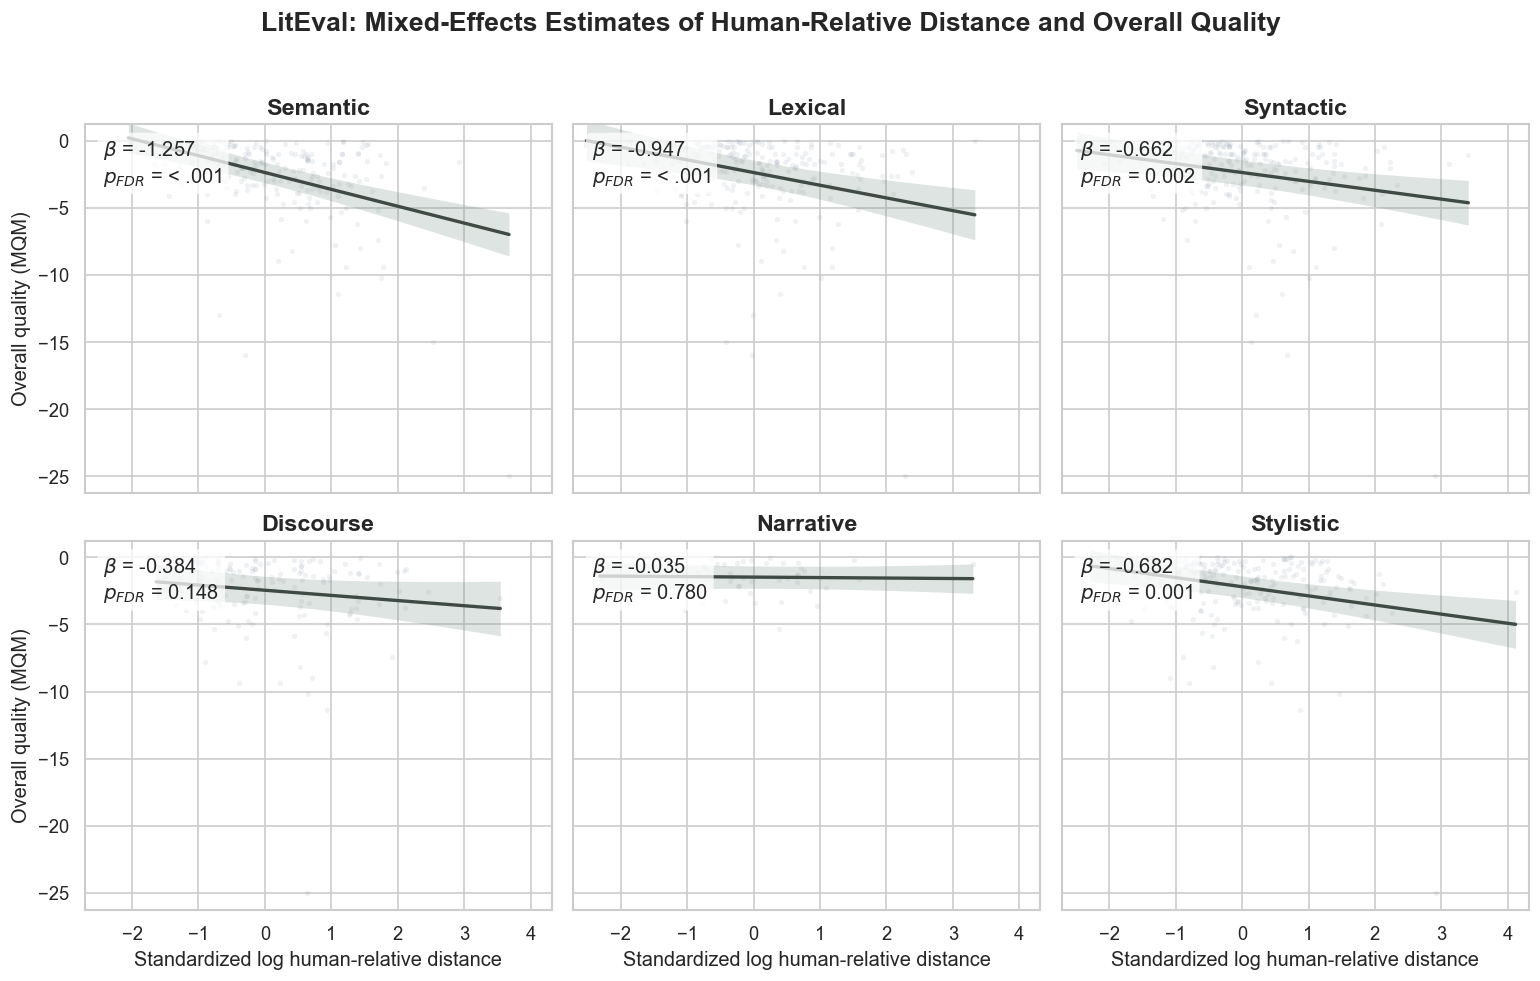

In [11]:
# Common y-axis limits
y_all = model_data[PRIMARY_TARGET]
y_pad = (y_all.max() - y_all.min()) * 0.05
YLIM = (y_all.min() - y_pad, y_all.max() + y_pad)

# Common x-axis limits across all six fitted models
x_all = np.concatenate([
    fit['data'][fit['predictor']].dropna().to_numpy()
    for fit in (primary_fits[(PRIMARY_TARGET, metric)] for metric in METRICS)
])
x_pad = (x_all.max() - x_all.min()) * 0.03
XLIM = (x_all.min() - x_pad, x_all.max() + x_pad)

fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharey=True, sharex=True)

for ax, metric in zip(axes.flat, METRICS):
    fit_info = primary_fits[(PRIMARY_TARGET, metric)]
    data = fit_info['data']
    predictor_col = fit_info['predictor']
    res = fit_info['result']
    row = primary_results[
        (primary_results.metric == metric) & (primary_results.target == PRIMARY_TARGET)
    ].iloc[0]

    x = data[predictor_col].to_numpy()
    y = data[PRIMARY_TARGET].to_numpy()
    ax.scatter(x, y, s=10, alpha=0.12, color='#7f91a3', linewidths=0)

    # Fixed-effect regression line + 95% Wald band (delta method on the [Intercept, slope] covariance)
    x_grid = np.linspace(x.min(), x.max(), 100)
    b0, b1 = res.params['Intercept'], res.params[predictor_col]
    cov_fe = res.cov_params().loc[['Intercept', predictor_col], ['Intercept', predictor_col]].to_numpy()
    X = np.column_stack([np.ones_like(x_grid), x_grid])
    y_hat = X @ np.array([b0, b1])
    se_hat = np.sqrt(np.einsum('ij,jk,ik->i', X, cov_fe, X))

    ax.fill_between(x_grid, y_hat - 1.96 * se_hat, y_hat + 1.96 * se_hat,
                     color='#7f9488', alpha=0.25, linewidth=0)
    ax.plot(x_grid, y_hat, color='#3f4a44', linewidth=2)

    p_fdr = row['p_fdr']
    p_label = '< .001' if p_fdr < 0.001 else f'{p_fdr:.3f}'
    ax.text(0.04, 0.96, f"$\\beta$ = {row['coef']:.3f}\n$p_{{FDR}}$ = {p_label}",
            transform=ax.transAxes, ha='left', va='top', fontsize=12,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.75, edgecolor='none'))

    ax.set_title(METRIC_LABELS[metric], fontsize=14, fontweight='bold')
    ax.set_ylim(*YLIM)
    ax.set_xlim(*XLIM)

for ax in axes[-1]:
    ax.set_xlabel('Standardized log human-relative distance', fontsize=12)
for ax in axes[:, 0]:
    ax.set_ylabel('Overall quality (MQM)', fontsize=12)

fig.suptitle('LitEval: Mixed-Effects Estimates of Human-Relative Distance and Overall Quality',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
save_figure('liteval_hrd_regression_panels.png')
plt.show()

## Robustness Checks

1. **Length control:** length mismatch as second predictor
2. **Nearest reference:** `r_nearest` instead of `r_mean`
3. **Three human translations:** segments with only two human translations dropped
4. **Nonlinearity:** quadratic `log(r)` term on the raw scale (Overall only)
5. **Segment 12:** Overall and nonlinearity models without the most influential segment

- Each check uses the same FDR families as the primary analysis

### Length Control

- Adds the mean absolute word-count difference to the segment's human translations as second predictor

In [12]:
length_results, length_fits, length_failures = fit_dimension_models(
    model_data,
    label='robustness_length_control',
    score_type='mean',
    include_length=True,
    length_col='length_mismatch_words',
)
length_results.to_csv(
    RESULTS_DIR / 'liteval_dimension_specific_mixedlm_length_control.csv', index=False
)

length_comparison = primary_results.merge(
    length_results,
    on=['target', 'metric'],
    suffixes=('_primary', '_length'),
    how='outer',
)
length_comparison.to_csv(
    RESULTS_DIR / 'liteval_dimension_specific_length_comparison.csv', index=False
)

if not length_failures.empty:
    print('Failed models:')
    display(length_failures)

display(length_comparison[[
    'target', 'metric', 'outcome_role_primary', 'dimension_role_primary',
    'coef_primary', 'ci_low_primary', 'ci_high_primary', 'p_fdr_primary',
    'coef_length', 'ci_low_length', 'ci_high_length', 'p_fdr_length',
    'n_primary', 'n_length', 'n_segments_primary', 'n_segments_length',
]].round(4))

,target,metric,outcome_role_primary,dimension_role_primary,coef_primary,ci_low_primary,ci_high_primary,p_fdr_primary,coef_length,ci_low_length,ci_high_length,p_fdr_length,n_primary,n_length,n_segments_primary,n_segments_length
0,MQM_Accuracy,disc,supplementary,confirmatory,-1.7074,-3.5733,0.1585,0.6153,-1.9418,-3.8370,-0.0465,0.3571,154,154,19,19
1,MQM_Accuracy,lex,supplementary,confirmatory,-0.9905,-2.8326,0.8515,0.6153,-1.3480,-3.3779,0.6819,0.4947,234,234,26,26
2,MQM_Accuracy,narr,supplementary,exploratory,-1.5331,-4.3539,1.2877,0.6153,-0.6612,-3.4345,2.1121,0.6681,44,44,6,6
3,MQM_Accuracy,sem,supplementary,confirmatory,-3.0890,-4.4892,-1.6889,0.0004,-3.5329,-5.0071,-2.0588,0.0001,234,234,26,26
4,MQM_Accuracy,style,supplementary,confirmatory,-1.1827,-2.7724,0.4070,0.6153,-1.4814,-3.1858,0.2229,0.4246,216,216,24,24
5,MQM_Accuracy,syn,supplementary,confirmatory,-0.5323,-1.9887,0.9242,0.6153,-0.7145,-2.2799,0.8509,0.4947,234,234,26,26
6,MQM_Fluency,disc,supplementary,confirmatory,0.1834,-0.2535,0.6203,0.6153,0.2093,-0.2222,0.6408,0.4947,154,154,19,19
7,MQM_Fluency,lex,supplementary,confirmatory,0.0489,-0.3297,0.4276,0.8001,0.1739,-0.1943,0.5421,0.4947,234,234,26,26
8,MQM_Fluency,narr,supplementary,exploratory,0.4954,-0.4966,1.4875,0.6153,0.6989,-0.4808,1.8787,0.4947,44,44,6,6
9,MQM_Fluency,sem,supplementary,confirmatory,-0.1534,-0.4801,0.1732,0.6153,-0.0419,-0.3757,0.2919,0.8057,234,234,26,26


### Nearest Human Reference

- `r_nearest`: distance to the closest human translation instead of the mean over all

In [13]:
nearest_results, nearest_fits, nearest_failures = fit_dimension_models(
    model_data,
    label='robustness_nearest_reference',
    score_type='nearest',
)
nearest_results.to_csv(
    RESULTS_DIR / 'liteval_dimension_specific_mixedlm_nearest_reference.csv', index=False
)

nearest_comparison = primary_results.merge(
    nearest_results,
    on=['target', 'metric'],
    suffixes=('_mean', '_nearest'),
    how='outer',
)
nearest_comparison.to_csv(
    RESULTS_DIR / 'liteval_dimension_specific_nearest_comparison.csv', index=False
)

if not nearest_failures.empty:
    print('Failed models:')
    display(nearest_failures)

display(nearest_comparison[[
    'target', 'metric', 'outcome_role_mean', 'dimension_role_mean',
    'coef_mean', 'ci_low_mean', 'ci_high_mean', 'p_fdr_mean',
    'coef_nearest', 'ci_low_nearest', 'ci_high_nearest', 'p_fdr_nearest',
    'n_mean', 'n_nearest', 'n_segments_mean', 'n_segments_nearest',
]].round(4))

,target,metric,outcome_role_mean,dimension_role_mean,coef_mean,ci_low_mean,ci_high_mean,p_fdr_mean,coef_nearest,ci_low_nearest,ci_high_nearest,p_fdr_nearest,n_mean,n_nearest,n_segments_mean,n_segments_nearest
0,MQM_Accuracy,disc,supplementary,confirmatory,-1.7074,-3.5733,0.1585,0.6153,-2.1868,-4.3466,-0.0269,0.2833,154,136,19,17
1,MQM_Accuracy,lex,supplementary,confirmatory,-0.9905,-2.8326,0.8515,0.6153,-0.8016,-2.6932,1.0900,0.6093,234,234,26,26
2,MQM_Accuracy,narr,supplementary,exploratory,-1.5331,-4.3539,1.2877,0.6153,-1.7878,-4.4684,0.8927,0.5753,44,44,6,6
3,MQM_Accuracy,sem,supplementary,confirmatory,-3.0890,-4.4892,-1.6889,0.0004,-3.8350,-5.3459,-2.3241,0.0000,234,234,26,26
4,MQM_Accuracy,style,supplementary,confirmatory,-1.1827,-2.7724,0.4070,0.6153,-1.2135,-2.9173,0.4903,0.5753,216,216,24,24
5,MQM_Accuracy,syn,supplementary,confirmatory,-0.5323,-1.9887,0.9242,0.6153,-0.2929,-1.7537,1.1680,0.8109,234,234,26,26
6,MQM_Fluency,disc,supplementary,confirmatory,0.1834,-0.2535,0.6203,0.6153,0.0683,-0.4204,0.5570,0.8183,154,136,19,17
7,MQM_Fluency,lex,supplementary,confirmatory,0.0489,-0.3297,0.4276,0.8001,0.0932,-0.2752,0.4615,0.7833,234,234,26,26
8,MQM_Fluency,narr,supplementary,exploratory,0.4954,-0.4966,1.4875,0.6153,0.4918,-0.5499,1.5335,0.6093,44,44,6,6
9,MQM_Fluency,sem,supplementary,confirmatory,-0.1534,-0.4801,0.1732,0.6153,-0.1860,-0.5165,0.1445,0.6093,234,234,26,26


### Segments with Three Human Translations

- Drops segments with only two human translations
- No recomputation: these segments already used three-human leave-one-out splits
- Narrative becomes even sparser

In [14]:
model_data_3ref = model_data.loc[
    model_data['Segment_ID'].isin(three_ref_segments)
].copy()

print(f'Sensitivity sample: {model_data_3ref["Segment_ID"].nunique()} segments, '
      f'{len(model_data_3ref)} model translations')

sensitivity_results, sensitivity_fits, sensitivity_failures = fit_dimension_models(
    model_data_3ref,
    label='robustness_three_human_references',
    score_type='mean',
)
sensitivity_results.to_csv(
    RESULTS_DIR / 'liteval_dimension_specific_mixedlm_3refs.csv', index=False
)

sensitivity_comparison = primary_results.merge(
    sensitivity_results,
    on=['target', 'metric'],
    suffixes=('_ge2', '_3refs'),
    how='outer',
)
sensitivity_comparison.to_csv(
    RESULTS_DIR / 'liteval_dimension_specific_3ref_comparison.csv', index=False
)

if not sensitivity_failures.empty:
    print('Failed models:')
    display(sensitivity_failures)

display(sensitivity_comparison[[
    'target', 'metric', 'outcome_role_ge2', 'dimension_role_ge2',
    'coef_ge2', 'ci_low_ge2', 'ci_high_ge2', 'p_fdr_ge2',
    'coef_3refs', 'ci_low_3refs', 'ci_high_3refs', 'p_fdr_3refs',
    'n_ge2', 'n_3refs', 'n_segments_ge2', 'n_segments_3refs',
]].round(4))

Sensitivity sample: 21 segments, 189 model translations


,target,metric,outcome_role_ge2,dimension_role_ge2,coef_ge2,ci_low_ge2,ci_high_ge2,p_fdr_ge2,coef_3refs,ci_low_3refs,ci_high_3refs,p_fdr_3refs,n_ge2,n_3refs,n_segments_ge2,n_segments_3refs
0,MQM_Accuracy,disc,supplementary,confirmatory,-1.7074,-3.5733,0.1585,0.6153,-0.8450,-3.0646,1.3747,0.6536,154,118,19,14
1,MQM_Accuracy,lex,supplementary,confirmatory,-0.9905,-2.8326,0.8515,0.6153,-1.2963,-3.3849,0.7924,0.6536,234,189,26,21
2,MQM_Accuracy,narr,supplementary,exploratory,-1.5331,-4.3539,1.2877,0.6153,-2.3269,-4.8381,0.1843,0.5070,44,43,6,5
3,MQM_Accuracy,sem,supplementary,confirmatory,-3.0890,-4.4892,-1.6889,0.0004,-2.9543,-4.6403,-1.2682,0.0143,234,189,26,21
4,MQM_Accuracy,style,supplementary,confirmatory,-1.1827,-2.7724,0.4070,0.6153,-1.1806,-2.9955,0.6344,0.6536,216,171,24,19
5,MQM_Accuracy,syn,supplementary,confirmatory,-0.5323,-1.9887,0.9242,0.6153,-0.8665,-2.5729,0.8399,0.6536,234,189,26,21
6,MQM_Fluency,disc,supplementary,confirmatory,0.1834,-0.2535,0.6203,0.6153,0.3107,-0.2382,0.8595,0.6536,154,118,19,14
7,MQM_Fluency,lex,supplementary,confirmatory,0.0489,-0.3297,0.4276,0.8001,0.0435,-0.4108,0.4979,0.9284,234,189,26,21
8,MQM_Fluency,narr,supplementary,exploratory,0.4954,-0.4966,1.4875,0.6153,0.4042,-0.6115,1.4200,0.6536,44,43,6,5
9,MQM_Fluency,sem,supplementary,confirmatory,-0.1534,-0.4801,0.1732,0.6153,-0.2432,-0.6366,0.1501,0.6536,234,189,26,21


### Nonlinearity

- `Overall ~ log r + (log r)^2 + (1 | Segment) + (1 | Model)` on the raw scale, where `log r = 0` ⇔ `r = 1`
- Linear term = slope at `r = 1`; FDR-corrected quadratic term = nonlinearity test

In [15]:
QUAD_TARGET = PRIMARY_TARGET
QUAD_TERM = 'I(log_r ** 2)'


def fit_quadratic_models(data, label):
    """`Overall ~ log_r + log_r^2` with crossed random intercepts, one model per dimension."""
    quad_rows = []
    quad_failures = []

    for metric in METRICS:
        predictor_col = f'log_r_{metric}'
        required = [predictor_col, QUAD_TARGET, 'Model', 'Segment_ID']
        prepared = data.dropna(subset=required).copy().reset_index(drop=False)

        try:
            if prepared.empty:
                raise ValueError('No complete cases remain.')

            # Raw scale (not z-scored): log_r == 0 <=> r == 1
            prepared = prepared.rename(columns={predictor_col: 'log_r'})
            model = crossed_mixedlm(f'{QUAD_TARGET} ~ log_r + {QUAD_TERM}', prepared)
            result, optimizer, fit_warnings = fit_robust_mixedlm(
                model, f'{label}/{QUAD_TARGET}/{metric}'
            )
        except Exception as error:
            quad_failures.append({'metric': metric, 'error': repr(error)})
            continue

        confidence = result.conf_int()
        segment_var, model_var, residual_var = get_variance_components(result)
        quad_rows.append({
            'metric': metric,
            'dimension_role': 'exploratory' if metric == 'narr' else 'confirmatory',
            'coef_linear_at_r1': result.params['log_r'],
            'ci_low_linear_at_r1': confidence.loc['log_r', 0],
            'ci_high_linear_at_r1': confidence.loc['log_r', 1],
            'p_linear_at_r1': result.pvalues['log_r'],
            'coef_quadratic': result.params[QUAD_TERM],
            'ci_low_quadratic': confidence.loc[QUAD_TERM, 0],
            'ci_high_quadratic': confidence.loc[QUAD_TERM, 1],
            'p_quadratic': result.pvalues[QUAD_TERM],
            'n': int(result.nobs),
            'n_segments': prepared['Segment_ID'].nunique(),
            'converged': bool(result.converged),
            'optimizer': optimizer,
            'segment_var': segment_var,
            'model_var': model_var,
            'residual_var': residual_var,
            'fit_warnings': ' | '.join(fit_warnings),
        })

    results = pd.DataFrame(quad_rows)
    failures = pd.DataFrame(quad_failures)

    if not results.empty:
        results['p_fdr_quadratic'] = multipletests(
            results['p_quadratic'], method='fdr_bh'
        )[1]
        results['sig_fdr_quadratic'] = results['p_fdr_quadratic'].apply(sig_stars)

    return results, failures


df_rob_quad, quad_failures = fit_quadratic_models(
    model_data,
    label='robustness_nonlinearity',
)
df_rob_quad.to_csv(
    RESULTS_DIR / 'liteval_overall_mixedlm_nonlinearity.csv',
    index=False,
)

if not quad_failures.empty:
    print('Failed models:')
    display(quad_failures)

print(f'Converged for all {len(df_rob_quad)} fits: {df_rob_quad["converged"].all()}')
print('Linear term = local slope at r=1; quadratic term = curvature (FDR-corrected p on the quadratic term):')
display(df_rob_quad.set_index('metric').reindex(METRICS).round(4))

Converged for all 6 fits: True
Linear term = local slope at r=1; quadratic term = curvature (FDR-corrected p on the quadratic term):


,dimension_role,coef_linear_at_r1,ci_low_linear_at_r1,ci_high_linear_at_r1,p_linear_at_r1,coef_quadratic,ci_low_quadratic,ci_high_quadratic,p_quadratic,n,n_segments,converged,optimizer,segment_var,model_var,residual_var,fit_warnings,p_fdr_quadratic,sig_fdr_quadratic
metric,,,,,,,,,,,,,,,,,,,
sem,confirmatory,-0.5377,-1.8643,0.7889,0.4269,-3.8803,-5.2758,-2.4849,0.0000,234,26,True,lbfgs,1.9957,0.6673,3.6617,divide by zero encountered in slogdet | invali...,0.0000,***
lex,confirmatory,-13.1875,-20.2153,-6.1598,0.0002,11.3148,-31.2905,53.9201,0.6027,234,26,True,lbfgs,2.8137,0.8486,4.5275,divide by zero encountered in slogdet | invali...,0.6027,
syn,confirmatory,-3.7132,-6.4555,-0.9708,0.0080,-7.5393,-16.2460,1.1674,0.0897,234,26,True,lbfgs,2.3304,1.1177,4.5976,divide by zero encountered in slogdet | invali...,0.1522,
disc,confirmatory,-1.1107,-2.0787,-0.1428,0.0245,0.5626,-0.1106,1.2358,0.1014,154,19,True,lbfgs,1.9012,1.2901,4.9343,,0.1522,
narr,exploratory,0.4894,-0.8470,1.8258,0.4729,1.8350,-0.8745,4.5445,0.1844,44,6,True,lbfgs,0.2598,0.8640,0.5005,,0.2213,
style,confirmatory,-1.7256,-3.2757,-0.1755,0.0291,-3.0055,-5.6183,-0.3927,0.0242,216,24,True,lbfgs,1.8316,0.7159,3.5868,divide by zero encountered in slogdet | invali...,0.0725,


### Robustness Overview

- Primary, length, nearest-reference and three-reference results side by side

In [16]:
all_dimension_results = pd.concat(
    [primary_results, length_results, nearest_results, sensitivity_results],
    ignore_index=True,
)
all_dimension_results.to_csv(
    RESULTS_DIR / 'liteval_dimension_specific_all_analyses_long.csv', index=False
)

comparison_fields = ['coef', 'ci_low', 'ci_high', 'p_fdr', 'n', 'n_segments', 'converged']
robustness_comparison = (
    all_dimension_results
    .set_index(['target', 'metric', 'analysis'])[comparison_fields]
    .unstack('analysis')
)
robustness_comparison.columns = [
    f'{field}_{analysis}' for field, analysis in robustness_comparison.columns
]
robustness_comparison = robustness_comparison.reset_index()
robustness_comparison.to_csv(
    RESULTS_DIR / 'liteval_dimension_specific_robustness_overview.csv', index=False
)
display(robustness_comparison.round(4))

,target,metric,coef_dimension_specific_mean_reference,coef_robustness_length_control,coef_robustness_nearest_reference,coef_robustness_three_human_references,ci_low_dimension_specific_mean_reference,ci_low_robustness_length_control,ci_low_robustness_nearest_reference,ci_low_robustness_three_human_references,...,n_robustness_nearest_reference,n_robustness_three_human_references,n_segments_dimension_specific_mean_reference,n_segments_robustness_length_control,n_segments_robustness_nearest_reference,n_segments_robustness_three_human_references,converged_dimension_specific_mean_reference,converged_robustness_length_control,converged_robustness_nearest_reference,converged_robustness_three_human_references
0,MQM_Accuracy,disc,-1.7074,-1.9418,-2.1868,-0.8450,-3.5733,-3.8370,-4.3466,-3.0646,...,136,118,19,19,17,14,True,True,True,True
1,MQM_Accuracy,lex,-0.9905,-1.3480,-0.8016,-1.2963,-2.8326,-3.3779,-2.6932,-3.3849,...,234,189,26,26,26,21,True,True,True,True
2,MQM_Accuracy,narr,-1.5331,-0.6612,-1.7878,-2.3269,-4.3539,-3.4345,-4.4684,-4.8381,...,44,43,6,6,6,5,True,True,True,True
3,MQM_Accuracy,sem,-3.0890,-3.5329,-3.8350,-2.9543,-4.4892,-5.0071,-5.3459,-4.6403,...,234,189,26,26,26,21,True,True,True,True
4,MQM_Accuracy,style,-1.1827,-1.4814,-1.2135,-1.1806,-2.7724,-3.1858,-2.9173,-2.9955,...,216,171,24,24,24,19,True,True,True,True
5,MQM_Accuracy,syn,-0.5323,-0.7145,-0.2929,-0.8665,-1.9887,-2.2799,-1.7537,-2.5729,...,234,189,26,26,26,21,True,True,True,True
6,MQM_Fluency,disc,0.1834,0.2093,0.0683,0.3107,-0.2535,-0.2222,-0.4204,-0.2382,...,136,118,19,19,17,14,True,True,True,True
7,MQM_Fluency,lex,0.0489,0.1739,0.0932,0.0435,-0.3297,-0.1943,-0.2752,-0.4108,...,234,189,26,26,26,21,True,True,True,True
8,MQM_Fluency,narr,0.4954,0.6989,0.4918,0.4042,-0.4966,-0.4808,-0.5499,-0.6115,...,44,43,6,6,6,5,True,True,True,True
9,MQM_Fluency,sem,-0.1534,-0.0419,-0.1860,-0.2432,-0.4801,-0.3757,-0.5165,-0.6366,...,234,189,26,26,26,21,True,True,True,True


### Excluding Segment 12

- Segment with the largest standardized residuals in the primary Overall models
- All six Overall models refit without it
- Stability judged by direction, size and confidence interval of each coefficient

In [17]:
INFLUENTIAL_SEGMENT = 12

segment_12_rows = model_data.loc[
    model_data['Segment_ID'] == INFLUENTIAL_SEGMENT
].copy()
if segment_12_rows.empty:
    raise ValueError(f'Segment {INFLUENTIAL_SEGMENT} is not present in model_data.')

model_data_without_12 = model_data.loc[
    model_data['Segment_ID'] != INFLUENTIAL_SEGMENT
].copy()

segment_12_results, segment_12_fits, segment_12_failures = fit_dimension_models(
    model_data_without_12,
    label='sensitivity_exclude_segment_12',
    score_type='mean',
    metrics=METRICS,
    targets=[PRIMARY_TARGET],
)
segment_12_results.to_csv(
    RESULTS_DIR / 'liteval_overall_mixedlm_exclude_segment_12.csv',
    index=False,
)

primary_overall_results = primary_results.loc[
    primary_results['target'] == PRIMARY_TARGET
].copy()
segment_12_comparison = primary_overall_results.merge(
    segment_12_results,
    on=['target', 'metric'],
    suffixes=('_full', '_without_12'),
    how='outer',
)
segment_12_comparison['coef_change'] = (
    segment_12_comparison['coef_without_12']
    - segment_12_comparison['coef_full']
)
segment_12_comparison['same_direction'] = (
    np.sign(segment_12_comparison['coef_without_12'])
    == np.sign(segment_12_comparison['coef_full'])
)
segment_12_comparison.to_csv(
    RESULTS_DIR / 'liteval_overall_segment_12_comparison.csv',
    index=False,
)

print(
    f'Excluded Segment {INFLUENTIAL_SEGMENT}: '
    f'{len(segment_12_rows)} model translations removed.'
)
if not segment_12_failures.empty:
    print('Failed sensitivity models:')
    display(segment_12_failures)

display(segment_12_comparison[[
    'target', 'metric', 'dimension_role_full',
    'coef_full', 'ci_low_full', 'ci_high_full', 'p_fdr_full',
    'coef_without_12', 'ci_low_without_12', 'ci_high_without_12',
    'p_fdr_without_12', 'coef_change', 'same_direction',
    'n_full', 'n_without_12', 'n_segments_full', 'n_segments_without_12',
    'converged_without_12', 'random_effect_boundary_without_12',
]].round(4))

Excluded Segment 12: 9 model translations removed.


,target,metric,dimension_role_full,coef_full,ci_low_full,ci_high_full,p_fdr_full,coef_without_12,ci_low_without_12,ci_high_without_12,p_fdr_without_12,coef_change,same_direction,n_full,n_without_12,n_segments_full,n_segments_without_12,converged_without_12,random_effect_boundary_without_12
0,Overall,disc,confirmatory,-0.3844,-0.8736,0.1049,0.1484,-0.2338,-0.5503,0.0827,0.2954,0.1506,True,154,145,19,18,True,False
1,Overall,lex,confirmatory,-0.9468,-1.4330,-0.4606,0.0004,-0.3214,-0.7504,0.1076,0.2954,0.6254,True,234,225,26,25,True,False
2,Overall,narr,exploratory,-0.0349,-0.2804,0.2105,0.7804,-0.0349,-0.2804,0.2105,0.7804,0.0000,True,44,44,6,6,True,False
3,Overall,sem,confirmatory,-1.2571,-1.6427,-0.8714,0.0000,-0.7313,-1.0554,-0.4072,0.0001,0.5258,True,234,225,26,25,True,False
4,Overall,style,confirmatory,-0.6816,-1.0689,-0.2944,0.0011,-0.0815,-0.3568,0.1938,0.6739,0.6001,True,216,207,24,23,True,False
5,Overall,syn,confirmatory,-0.6616,-1.0659,-0.2573,0.0020,-0.1712,-0.5104,0.1680,0.4840,0.4904,True,234,225,26,25,True,False


### Nonlinearity without Segment 12

- Quadratic Overall models refit without Segment 12: does any curvature persist?

In [18]:
df_rob_quad_without_12, quad_without_12_failures = fit_quadratic_models(
    model_data_without_12,
    label='sensitivity_nonlinearity_exclude_segment_12',
)
df_rob_quad_without_12.to_csv(
    RESULTS_DIR / 'liteval_overall_mixedlm_nonlinearity_exclude_segment_12.csv',
    index=False,
)

if not quad_without_12_failures.empty:
    print('Failed models:')
    display(quad_without_12_failures)

quad_segment_12_comparison = (
    df_rob_quad[[
        'metric', 'coef_quadratic', 'ci_low_quadratic', 'ci_high_quadratic',
        'p_quadratic', 'p_fdr_quadratic', 'n', 'n_segments'
    ]]
    .merge(
        df_rob_quad_without_12[[
            'metric', 'coef_quadratic', 'ci_low_quadratic', 'ci_high_quadratic',
            'p_quadratic', 'p_fdr_quadratic', 'n', 'n_segments'
        ]],
        on='metric',
        suffixes=('_full', '_without_12'),
        how='outer',
    )
)
quad_segment_12_comparison['quadratic_coef_change'] = (
    quad_segment_12_comparison['coef_quadratic_without_12']
    - quad_segment_12_comparison['coef_quadratic_full']
)
quad_segment_12_comparison.to_csv(
    RESULTS_DIR / 'liteval_nonlinearity_segment_12_comparison.csv',
    index=False,
)

display(
    quad_segment_12_comparison
    .set_index('metric')
    .reindex(METRICS)
    .round(4)
)

,coef_quadratic_full,ci_low_quadratic_full,ci_high_quadratic_full,p_quadratic_full,p_fdr_quadratic_full,n_full,n_segments_full,coef_quadratic_without_12,ci_low_quadratic_without_12,ci_high_quadratic_without_12,p_quadratic_without_12,p_fdr_quadratic_without_12,n_without_12,n_segments_without_12,quadratic_coef_change
metric,,,,,,,,,,,,,,,
sem,-3.8803,-5.2758,-2.4849,0.0000,0.0000,234,26,-0.2557,-1.7083,1.1969,0.7301,0.8761,225,25,3.6246
lex,11.3148,-31.2905,53.9201,0.6027,0.6027,234,26,37.0420,1.6144,72.4695,0.0404,0.2426,225,25,25.7272
syn,-7.5393,-16.2460,1.1674,0.0897,0.1522,234,26,2.4987,-4.7010,9.6983,0.4964,0.8761,225,25,10.0380
disc,0.5626,-0.1106,1.2358,0.1014,0.1522,154,19,0.1007,-0.3282,0.5296,0.6455,0.8761,145,18,-0.4619
narr,1.8350,-0.8745,4.5445,0.1844,0.2213,44,6,1.8350,-0.8745,4.5445,0.1844,0.5531,44,6,0.0000
style,-3.0055,-5.6183,-0.3927,0.0242,0.0725,216,24,0.0394,-1.7676,1.8465,0.9659,0.9659,207,23,3.0450
